In [2]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [6]:
# Get gene trait associations
RAP_DIR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results'

# ASSOC_FILE = 'loftee_mac20_associations_bh_corrected.parquet'
# ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR.parquet'
ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquet'

LOCAL_DIR = '/home/dnanexus/data_dir/'

!dx download {RAP_DIR}/{ASSOC_FILE} -o {LOCAL_DIR}

gene_trait_df = (
    pl.read_parquet(f'{LOCAL_DIR}/{ASSOC_FILE}')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

CORR_FILE = 'regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet'
!dx download {RAP_DIR}/{CORR_FILE} -o {LOCAL_DIR}

loftee_corrs = (
    pl.read_parquet(f'{LOCAL_DIR}/{CORR_FILE}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    .unique(subset=["region"], keep="first", maintain_order=True)
)

gene_trait_df = gene_trait_df.filter(pl.col('phenotype')=='ldl_direct_int')
gene_trait_df

Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_
correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000084674""","""ldl_direct_int""",2.2543e-301,-0.241637,0.241637,-1.0
"""ENSG00000183087""","""ldl_direct_int""",0.011205,0.18305,0.18305,1.0
"""ENSG00000135100""","""ldl_direct_int""",0.003664,-0.170468,0.170468,-1.0
"""ENSG00000197879""","""ldl_direct_int""",0.047093,-0.084917,0.084917,-1.0


In [7]:
# Configuration and paths
mac = 20
pheno_list_type = None
# pheno_list_type = 'biochemistry'
# pheno_list_type = 'overall_phenotype'

new_anno_local = None

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_odds.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""missense""","""am_pathogenicity""","""#FFCA28""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#FB8C00""","""ESM1v""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""conservation""","""gpn_score""","""pink""","""GPN-MSA""",-1
"""conservation""","""verphylop""","""#483D8B""","""Vertebrate PhyloP""",1
…,…,…,…,…
"""regulatory_nondir""","""promoterai_abs""","""#00838F""","""PromoterAI abs""",1
"""regulatory_nondir""","""abexp_abs_max""","""#80CBC4""","""AbExp abs max""",1
"""regulatory_nondir""","""fz_RNA_all_abs_max""","""#FFA500""","""Flashzoi abs max across RNA al…",1


In [8]:
# new_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/flashzoi_scores"
# new_anno_filename = "TSS_flashzoi_EURunrelated_variants_burden_test_olink_genes_GENCODEv40_ukbbgym.parquet"
# !dx download {new_anno_path}/{new_anno_filename} -o /home/dnanexus/data_dir/

# new_anno_local = f'/home/dnanexus/data_dir/{new_anno_filename}'

# new_anno_df = (
#     pl.read_parquet(new_anno_local)
#     .filter(pl.col('region').is_in(olink_whitelist['region'].unique()))
#     .with_columns(
#         fz_all_mean = pl.mean_horizontal(cs.starts_with('RNA:').abs()),
#         fz_blood_mean = pl.mean_horizontal(pl.col(['RNA:blood_7531', 'RNA:blood_7532', 'RNA:blood_7533']).abs()),
#     )
#     .select(['id', 'region', 'fz_blood_mean', 'fz_all_mean'])
#     .lazy()
# )

# new_anno_df.head().collect()

In [53]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym.parquet"
ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

min_range = -500
max_range = +500

# Join new annotation if specified above
if new_anno_local is not None:
    anno = (
        anno
        .join(
            new_anno_df,
            on=['id', 'region'],
            how='left'
        )
    )

anno = (
    anno
    .filter(
        # Filter to gene regions of interest
        (pl.col('region').is_in(gene_trait_df['region'].unique())),
        
        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True),

        # Choose non CDS only
        # UPDATE WITH NEW VEP MANE ANNOS
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)),
        
        # Choose Gene Body
        # ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False)),

        # Choose VEP consequence
        # (pl.col('consequence_missense_variant') == True),
        # (pl.any_horizontal(cs.contains("consequence_splice") == True)),

        # Core promoter
        # (pl.col('promoterai_is_na') == False),

        # Choose Introns with/without alternate CDS
        # (pl.col('consequence_intron_variant') == True),
        # ((pl.col('consequence_intron_variant') == True) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)),

        # Choose pLoF variants
        # (pl.col('loftee_hc') == True),

        # Choose protein domain
        # (pl.col('ted_domain') == True),
        # (pl.col('mobi_curated_disorder_priority') == True),
        # (pl.col('mobi_lip_full') == True),
        # (pl.col('low_complexity_domain') == True),

        # Choose regulatory region
        # (pl.col('not_in_encode') == False),
        # (pl.col('encode_eh_pr') == True),
        # (pl.col('encode_all_tf') == True),

        # Distance to TSS range
        # (pl.col('dist_to_tss') >= min_range),
        # (pl.col('dist_to_tss') <= max_range),

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .with_columns(
        promoterai_abs = pl.col('promoterai').abs(),
    )
)

selected_categories = ['missense', 'genetic_diversity'] # Gene-Body
# selected_categories = ['missense', 'genetic_diversity', 'conservation', 'splicing', 'regulatory_nondir'] # Gene-Body

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
selected_annos = list(set(selected_annos).intersection(set(existing_annos)))
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
)


anno

Error: path
"/home/dnanexus/data_dir/annotations_fillna_ukbgym_with_mane.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_257592/2763667779.py:84: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_257592/2763667779.py:93: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


am_pathogenicity,esmscoremissense,id,cadd_raw,region
f32,f32,str,f32,str
0.0,0.0,"""chr2:20998628:C:T""",0.436671,"""ENSG00000084674"""
0.0,0.0,"""chr12:121005783:G:A""",0.565137,"""ENSG00000135100"""
0.0,0.0,"""chr17:1468901:T:G""",-0.035159,"""ENSG00000197879"""
0.0,0.0,"""chr17:1479093:C:G""",0.150592,"""ENSG00000197879"""
0.0,0.0,"""chr13:113851987:T:C""",0.307916,"""ENSG00000183087"""
…,…,…,…,…
0.0,0.0,"""chr2:20999882:G:A""",0.45694,"""ENSG00000084674"""
0.0,0.0,"""chr12:120989293:T:A""",0.310335,"""ENSG00000135100"""
0.0,0.0,"""chr13:113862851:G:C""",0.227313,"""ENSG00000183087"""


In [54]:
anno_fillna = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
fillna_cols = set([c+'_is_na' for c in existing_annos]).intersection(set(anno_fillna.collect_schema().names()))

anno_fillna_melted = (
    anno_fillna
    .filter(pl.col('region').is_in(gene_trait_df['region'].unique()))
    .select(['id', 'region'] + list(fillna_cols))
    .join(
        anno.select(['id', 'region']).lazy(), 
        on=['id', 'region'], 
        how='semi'
    )
    .unpivot(
        index=["id", "region"],
        on=list(fillna_cols),
        variable_name="annotation",
        value_name="annotation_is_na"
    )
    .filter(
        pl.col('annotation_is_na') == 1
    )
    .with_columns(
        annotation = pl.col('annotation').str.replace('_is_na$', '')
    )
    # .collect(engine='streaming')
)

anno_fillna_melted.head().collect()

/tmp/ipykernel_257592/2939847608.py:28: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_is_na
str,str,str,i8
"""chr2:20998628:C:T""","""ENSG00000084674""","""absplice2_max""",1
"""chr12:121005783:G:A""","""ENSG00000135100""","""absplice2_max""",1
"""chr2:21045906:A:G""","""ENSG00000084674""","""absplice2_max""",1
"""chr13:113816839:C:A""","""ENSG00000183087""","""absplice2_max""",1
"""chr17:1460639:T:A""","""ENSG00000197879""","""absplice2_max""",1


In [55]:
melted_anno = (
    anno.lazy()

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]).lazy(),
        on="annotation",
        how="left"
    )
    .filter(pl.col('category').is_in(selected_categories))
    .unique()

    # Remove null annotation scores
    .drop_nulls('annotation_score')

    # Keep variants that don't have fillna annotation
    .join(
        anno_fillna_melted,
        on=['id', 'region', 'annotation'],
        how='anti'
    )

    # Correct scores by annotation direction
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        annotation_score_dircor_rank_desc = pl.col('annotation_score_dircor').rank(method="max", descending=True).over(["annotation"]).cast(pl.Float32)
    )
    # .drop(['annotation_score_dircor'])

    .collect(engine='streaming')
)

melted_anno

/tmp/ipykernel_257592/2762883517.py:45: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor,annotation_score_dircor_rank_desc
str,str,str,f32,str,i8,f32,f32
"""chr17:1460129:A:G""","""ENSG00000197879""","""cadd_raw""",-0.245784,"""genetic_diversity""",1,-0.245784,38731.0
"""chr2:21019279:G:C""","""ENSG00000084674""","""cadd_raw""",0.374451,"""genetic_diversity""",1,0.374451,16352.0
"""chr17:1475012:C:T""","""ENSG00000197879""","""cadd_raw""",3.545644,"""genetic_diversity""",1,3.545644,1625.0
"""chr17:1469982:C:A""","""ENSG00000197879""","""cadd_raw""",0.187402,"""genetic_diversity""",1,0.187402,24912.0
"""chr12:121000924:G:A""","""ENSG00000135100""","""cadd_raw""",0.679588,"""genetic_diversity""",1,0.679588,8751.0
…,…,…,…,…,…,…,…
"""chr17:1485820:C:A""","""ENSG00000197879""","""cadd_raw""",1.338039,"""genetic_diversity""",1,1.338039,4570.0
"""chr2:21004222:T:G""","""ENSG00000084674""","""cadd_raw""",-0.153322,"""genetic_diversity""",1,-0.153322,36932.0
"""chr2:21003634:G:C""","""ENSG00000084674""","""cadd_raw""",0.17265,"""genetic_diversity""",1,0.17265,25614.0


In [56]:
anno['region'].value_counts(sort=True).filter(pl.col('count')>=50)

region,count
str,u64
"""ENSG00000183087""",13704
"""ENSG00000084674""",12197
"""ENSG00000197879""",11204
"""ENSG00000135100""",7361


In [57]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus/data_dir"

# APPV_FILE = "loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet"
APPV_FILE = "quant_pheno_loftee_mac20_EURunrelated_miss20per_appv_percentiles.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('phenotype').is_in(gene_trait_df['phenotype'].unique())
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'mean_pheno_value_ptile']
    )
    .collect()
)

appv

Error: path "/home/dnanexus/data_dir/quant_pheno_loftee_mac20_EURunrelated_mis
s20per_appv_percentiles.parquet" already exists but -f/--overwrite was not set


/tmp/ipykernel_257592/3753896679.py:25: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,phenotype,mean_pheno_value,mean_pheno_value_ptile
str,str,f32,f32
"""chr17:1496310:G:C""","""ldl_direct_int""",0.270839,0.29348
"""chr17:1497597:C:T""","""ldl_direct_int""",0.750369,0.100597
"""chr17:1496749:T:C""","""ldl_direct_int""",0.247478,0.308398
"""chr17:1497293:T:C""","""ldl_direct_int""",-0.320828,0.737011
"""chr17:1496318:C:T""","""ldl_direct_int""",-0.300472,0.725314
…,…,…,…
"""chr12:120996912:C:A""","""ldl_direct_int""",0.26421,0.297648
"""chr12:121003448:G:C""","""ldl_direct_int""",0.82757,0.084339
"""chr12:120991937:G:T""","""ldl_direct_int""",-2.188851,0.99664


In [65]:
# --- Setup ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())

# Unique (id, region) mapping — needed to get region before annotation join
id_region_lazy = anno.select(['id', 'region']).unique().lazy()

# --- Compute both percentile approaches on unique (id, region, phenotype) rows ---
gp_lazy = (
    appv.lazy()
    .join(anno_ids_lazy, on="id", how="semi")

    # Bring in region (before annotation join to avoid duplication)
    .join(id_region_lazy, on='id', how='inner')

    # Bring in gene-trait info (loftee_corr_dir etc.)
    .join(gene_trait_df.lazy(), on=["region", "phenotype"], how="inner")

    # Approach 1: GLOBAL percentile — rank across all variants per phenotype
    .with_columns(
        global_ptile = (
            pl.col('mean_pheno_value')
                .rank(method="max")
                .over('phenotype')
                .cast(pl.Float32)
            / pl.len().over('phenotype').cast(pl.Float32)
        ),
    )

    # Approach 2: GENE-SPECIFIC percentile — rank within each gene
    .with_columns(
        gene_ptile = (
            pl.col('mean_pheno_value')
                .rank(method="max")
                .over(['region', 'phenotype'])
                .cast(pl.Float32)
            / pl.len().over(['region', 'phenotype']).cast(pl.Float32)
        ),
    )

    # Direction correction for both
    .with_columns(
        global_ptile_dircor = pl.when(pl.col('loftee_corr_dir') == -1)
            .then(1 - pl.col('global_ptile'))
            .otherwise(pl.col('global_ptile')),
        gene_ptile_dircor = pl.when(pl.col('loftee_corr_dir') == -1)
            .then(1 - pl.col('gene_ptile'))
            .otherwise(pl.col('gene_ptile')),
    )

    # NOW join with annotations (this duplicates rows per annotation, but percentiles are already computed)
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_nan' in c]),
        on=["id", "region"],
        how="inner"
    )
    .collect()
)

gp_lazy


id,phenotype,mean_pheno_value,mean_pheno_value_ptile,region,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,global_ptile,gene_ptile,global_ptile_dircor,gene_ptile_dircor,annotation,annotation_score,category,annotation_dir,annotation_score_dircor,annotation_score_dircor_rank_desc
str,str,f32,f32,str,f64,f64,f64,f64,f32,f32,f32,f32,str,f32,str,i8,f32,f32
"""chr17:1460129:A:G""","""ldl_direct_int""",1.044092,0.052307,"""ENSG00000197879""",0.047093,-0.084917,0.084917,-1.0,0.925858,0.926861,0.074142,0.073139,"""cadd_raw""",-0.245784,"""genetic_diversity""",1,-0.245784,38731.0
"""chr2:21019279:G:C""","""ldl_direct_int""",-0.405015,0.780801,"""ENSG00000084674""",2.2543e-301,-0.241637,0.241637,-1.0,0.256288,0.273328,0.743712,0.726672,"""cadd_raw""",0.374451,"""genetic_diversity""",1,0.374451,16352.0
"""chr17:1475012:C:T""","""ldl_direct_int""",-0.180471,0.646596,"""ENSG00000197879""",0.047093,-0.084917,0.084917,-1.0,0.37621,0.373751,0.62379,0.626248,"""cadd_raw""",3.545644,"""genetic_diversity""",1,3.545644,1625.0
"""chr17:1469982:C:A""","""ldl_direct_int""",-1.396549,0.975284,"""ENSG00000197879""",0.047093,-0.084917,0.084917,-1.0,0.040491,0.036409,0.959509,0.963591,"""cadd_raw""",0.187402,"""genetic_diversity""",1,0.187402,24912.0
"""chr12:121000924:G:A""","""ldl_direct_int""",0.120485,0.400509,"""ENSG00000135100""",0.003664,-0.170468,0.170468,-1.0,0.580036,0.575055,0.419964,0.424945,"""cadd_raw""",0.679588,"""genetic_diversity""",1,0.679588,8751.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr17:1485820:C:A""","""ldl_direct_int""",-0.907317,0.928222,"""ENSG00000197879""",0.047093,-0.084917,0.084917,-1.0,0.103347,0.097949,0.896653,0.902051,"""cadd_raw""",1.338039,"""genetic_diversity""",1,1.338039,4570.0
"""chr2:21004222:T:G""","""ldl_direct_int""",0.510863,0.173783,"""ENSG00000084674""",2.2543e-301,-0.241637,0.241637,-1.0,0.790781,0.794189,0.209219,0.205811,"""cadd_raw""",-0.153322,"""genetic_diversity""",1,-0.153322,36932.0
"""chr2:21003634:G:C""","""ldl_direct_int""",-0.868775,0.92203,"""ENSG00000084674""",2.2543e-301,-0.241637,0.241637,-1.0,0.110661,0.123394,0.889339,0.876606,"""cadd_raw""",0.17265,"""genetic_diversity""",1,0.17265,25614.0


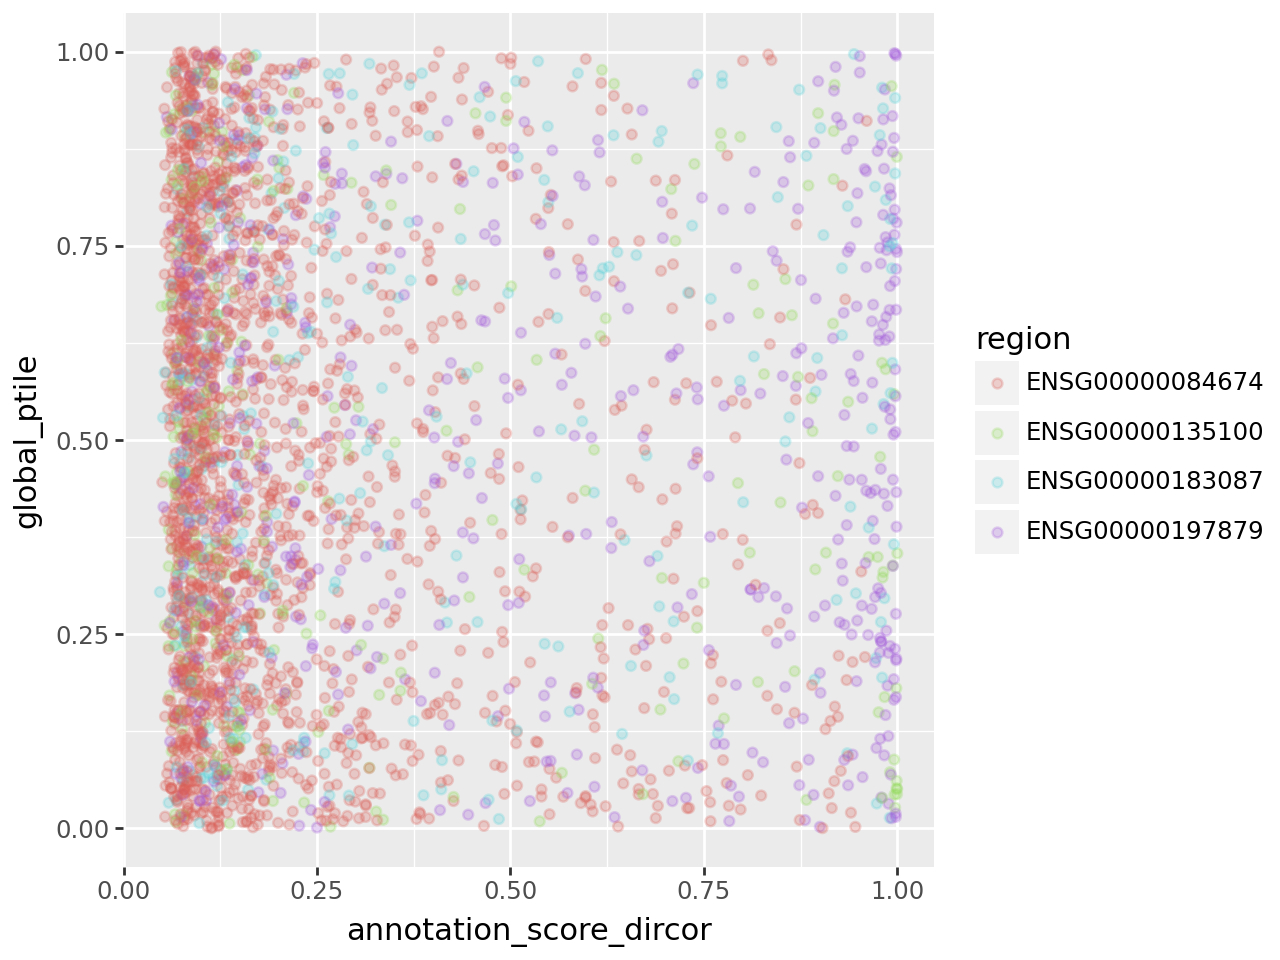

In [68]:
(
    ggplot(gp_lazy.filter(pl.col('annotation')=='am_pathogenicity'))
    + geom_point(aes(x='annotation_score_dircor', y='global_ptile', color='region'), alpha=0.25)
)

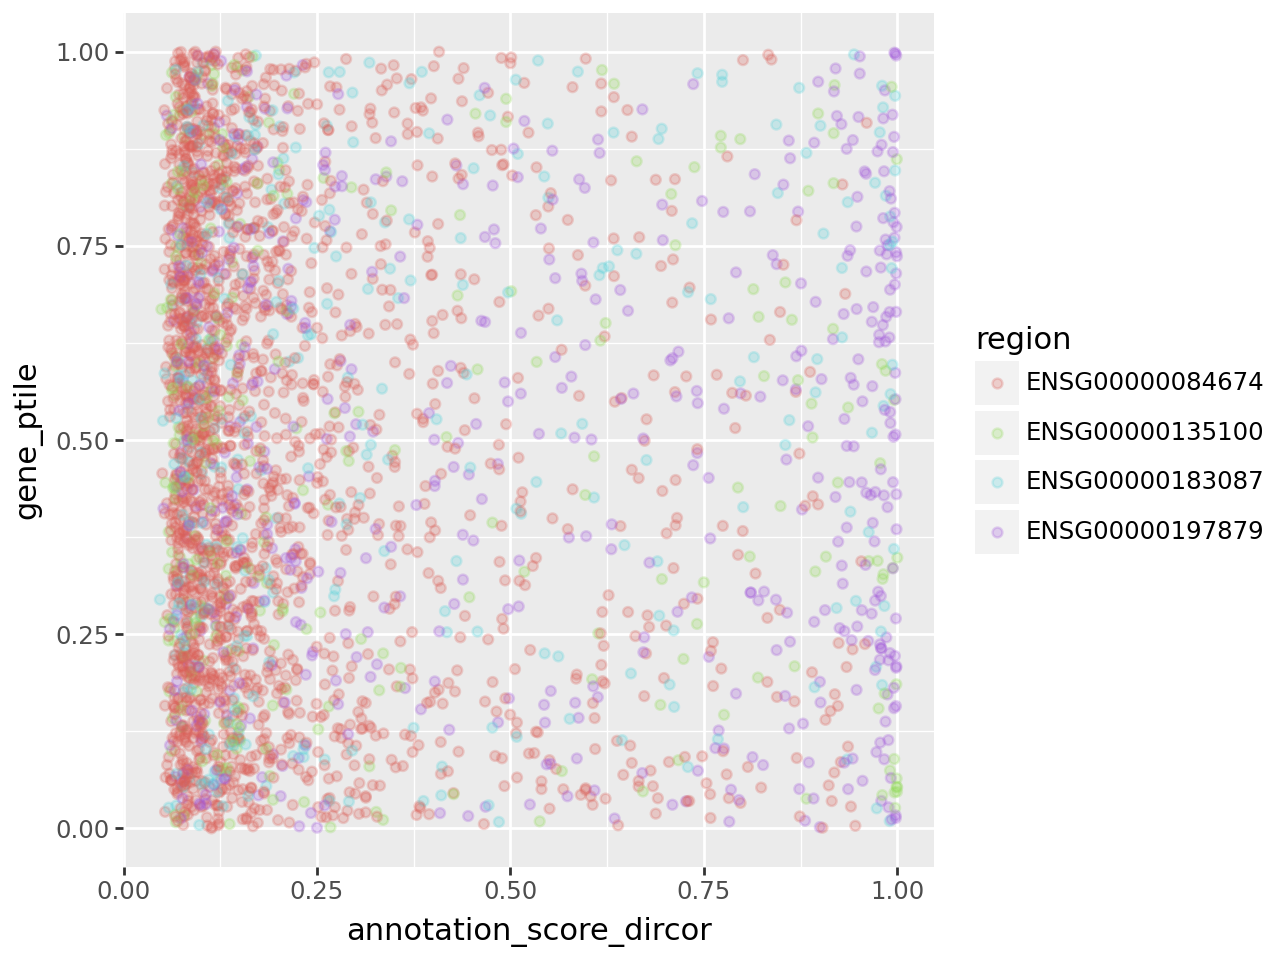

In [69]:
(
    ggplot(gp_lazy.filter(pl.col('annotation')=='am_pathogenicity'))
    + geom_point(aes(x='annotation_score_dircor', y='gene_ptile', color='region'), alpha=0.25)
)

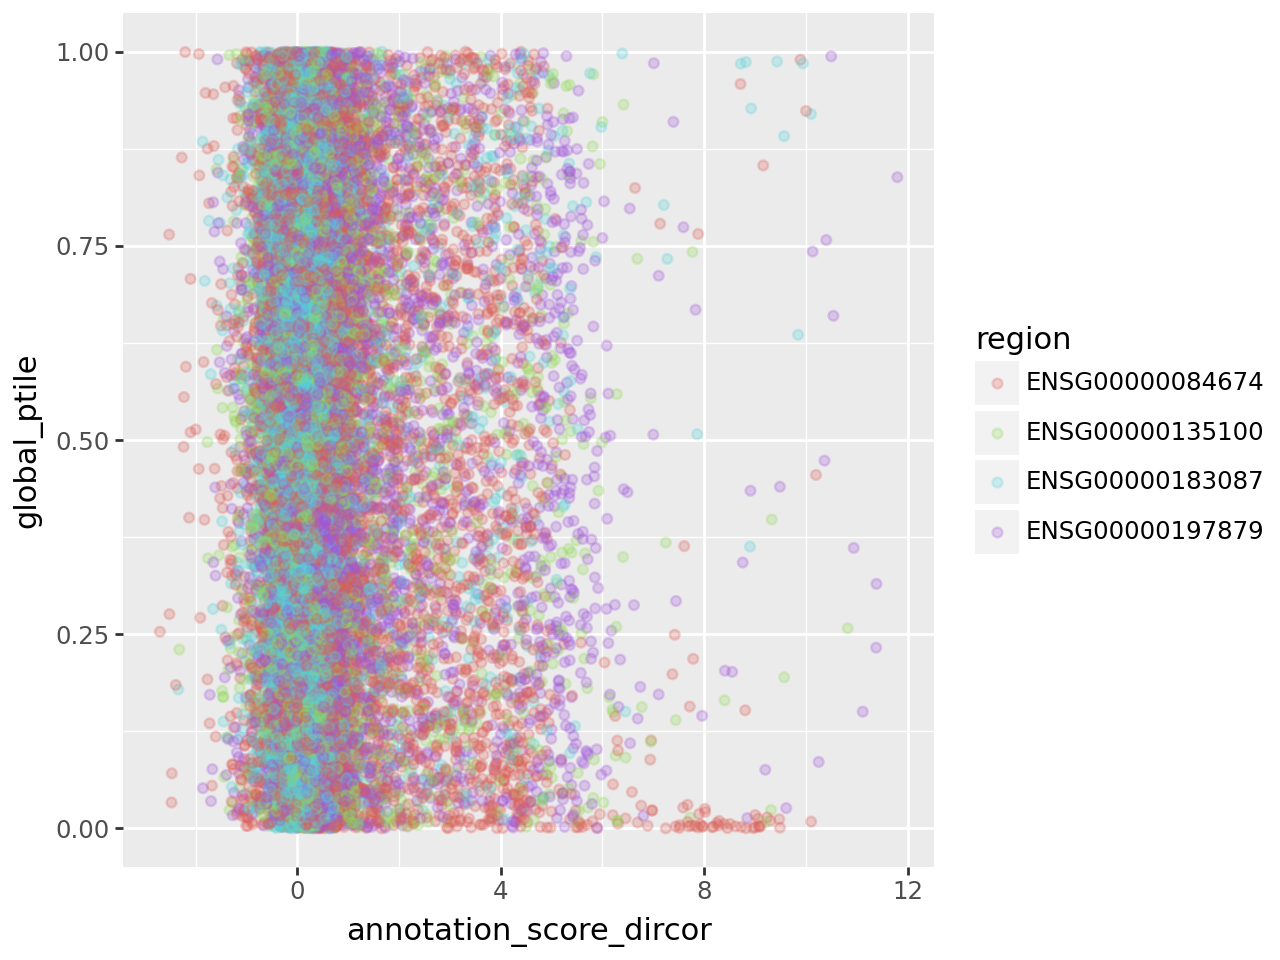

In [71]:
(
    ggplot(gp_lazy.filter(pl.col('annotation')=='cadd_raw'))
    + geom_point(aes(x='annotation_score_dircor', y='global_ptile', color='region'), alpha=0.25)
)

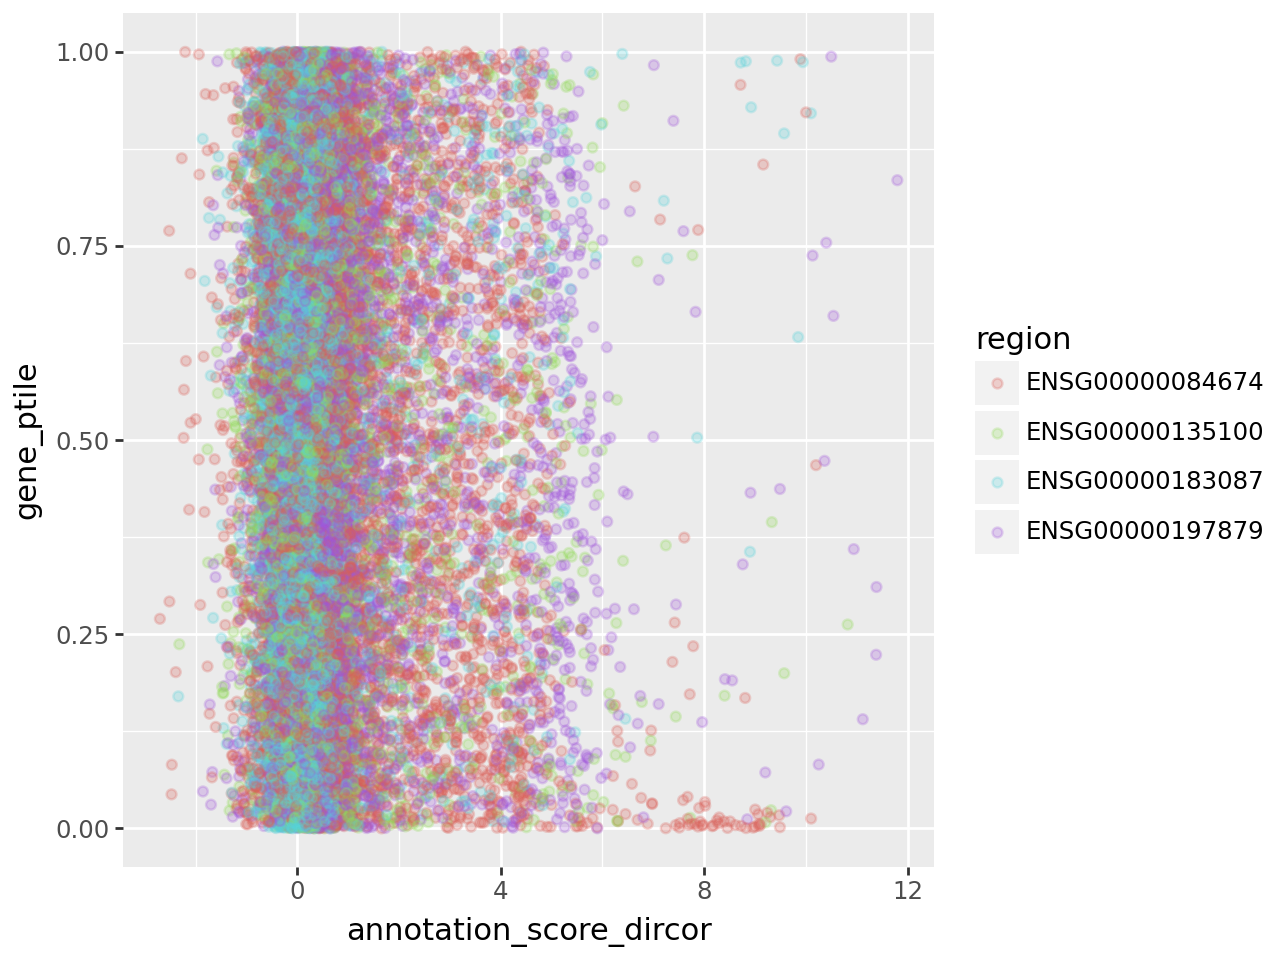

In [72]:
(
    ggplot(gp_lazy.filter(pl.col('annotation')=='cadd_raw'))
    + geom_point(aes(x='annotation_score_dircor', y='gene_ptile', color='region'), alpha=0.25)
)

## Odds ratio computation

In [58]:
n_steps = 101
min_rank_cutoff = 1_000
max_rank_cutoff = 10_000_000
max_rank_cutoff = np.min([max_rank_cutoff, anno.shape[0]])
or_threshold_pheno = 0.99

# We assume that all models score the same number of variants (all the variants in 'anno')
log_steps = np.geomspace(min_rank_cutoff, max_rank_cutoff, n_steps)

cutoffs_lazy = pl.LazyFrame({"rank_cutoff": log_steps.astype(int)})

cutoffs_lazy.collect()

rank_cutoff
i64
1000
1038
1078
1120
1163
…
38203
39681
41216


In [62]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- Build main query (same as before, but stop before group_by) ---
gp_lazy = (
    appv.lazy()
    .join(
        anno_ids_lazy, 
        on="id", 
        how="semi"
    )
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_nan' in c]), 
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor = pl.col('mean_pheno_value')*pl.col('loftee_corr_dir')
    )

    .group_by(['region'])
    .with_columns(
        mean_pheno_value_dircor_rank = pl.col('mean_pheno_value_dircor').rank(method="max")
    )
    .with_columns(
        mean_pheno_value_dircor_ptile = pl.col('mean_pheno_value_dircor_rank') / pl.len()
    )
    # .with_columns(
    #     mean_pheno_value_dircor_ptile_precomp = pl.when(pl.col('loftee_corr_dir') == -1)
    #         .then(1 - pl.col('mean_pheno_value_ptile'))
    #         .otherwise(pl.col('mean_pheno_value_ptile')),
    # )
    .collect()
)

gp_lazy

AttributeError: 'LazyGroupBy' object has no attribute 'with_columns'

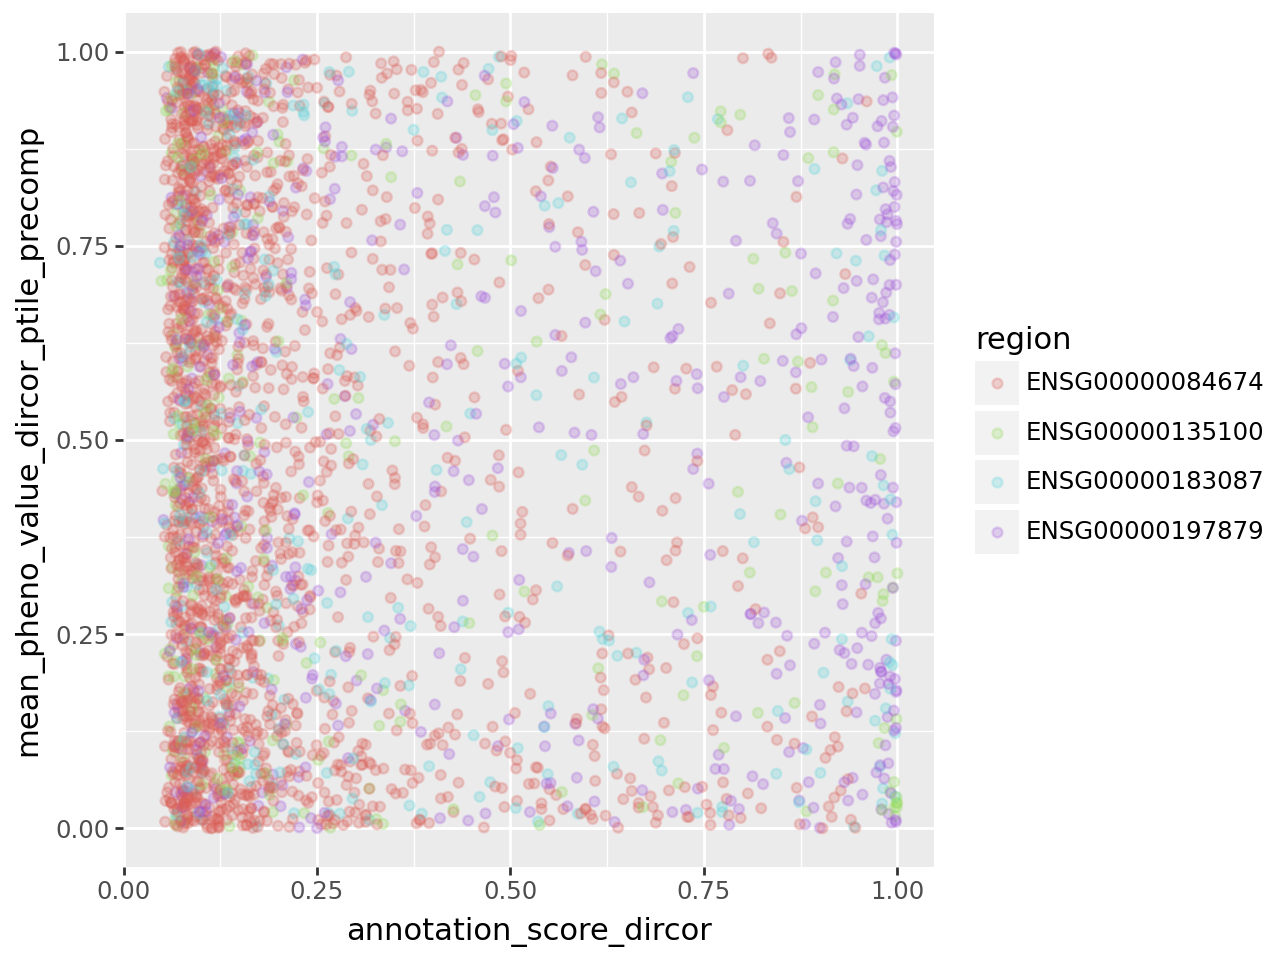

In [60]:
(
    ggplot(gp_lazy.filter(pl.col('annotation')=='am_pathogenicity'))
    + geom_point(aes(x='annotation_score_dircor', y='mean_pheno_value_dircor_ptile_precomp', color='region'), alpha=0.25)
)

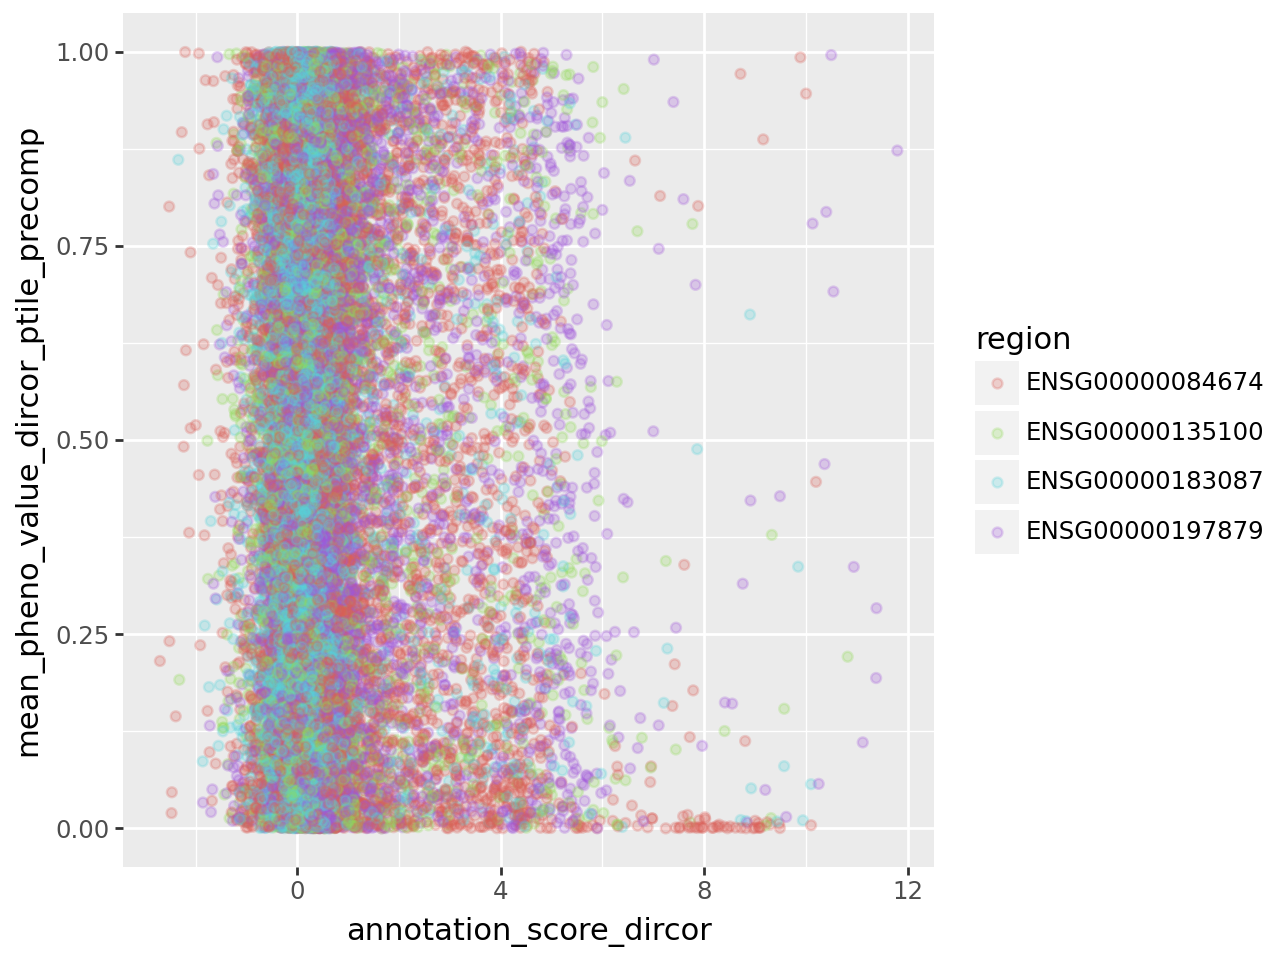

In [61]:
(
    ggplot(gp_lazy.filter(pl.col('annotation')=='cadd_raw'))
    + geom_point(aes(x='annotation_score_dircor', y='mean_pheno_value_dircor_ptile_precomp', color='region'), alpha=0.25)
)

In [ ]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- Build main query (same as before, but stop before group_by) ---
gp_lazy = (
    appv
    .join(
        anno_ids_lazy, 
        on="id", 
        how="semi"
    )
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_nan' in c]), 
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor_ptile = pl.when(pl.col('loftee_corr_dir') == -1)
            .then(1 - pl.col('mean_pheno_value_ptile'))
            .otherwise(pl.col('mean_pheno_value_ptile')),
    )
)

# Cross join with cutoffs and compute odds ratios
or_lazy = (
    gp_lazy
    .select(["annotation", "region", "phenotype", "annotation_score_dircor_rank_desc", "mean_pheno_value_dircor_ptile"])
    .join(cutoffs_lazy, how="cross")
    .group_by(["annotation", "rank_cutoff"])
    .agg(
        n_dis_above_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") <= pl.col("rank_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_above_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") <= pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum(),
        n_dis_below_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") > pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_below_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") > pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum()
    )
    .with_columns(
        odds_ratio = (pl.col("n_dis_above_cutoff") / pl.col("n_notdis_above_cutoff")) / (pl.col("n_dis_below_cutoff") / pl.col("n_notdis_below_cutoff"))
    )
)

# Execute
print("Executing with odds ratios...")
or_df = or_lazy.collect(engine='streaming').sort('rank_cutoff', descending=True)

or_df

Executing with odds ratios...


In [ ]:
# or_df.write_parquet("/home/dnanexus/data_dir/gene_body_pheno_odds_ratio.parquet")

## Plotting

In [12]:
print('unique percentile cutoffs:', or_df['rank_cutoff'].n_unique())

plt_df = (
    or_df
    .drop_nans()
    .filter(pl.col("odds_ratio").is_finite())
    .with_columns(
        n_gene_phenos = pl.len().over(['rank_cutoff', 'annotation']),
        log_rank_cutoff = np.log10(pl.col('rank_cutoff')),
        log_rank_cutoff_inv = np.log10(1/pl.col('rank_cutoff')),
    )
    .with_columns(
        med_odds_ratio = pl.col('odds_ratio').median().over(['rank_cutoff', 'annotation']),
        avg_odds_ratio = pl.col('odds_ratio').mean().over(['rank_cutoff', 'annotation']),
        se_odds_ratio = pl.col('odds_ratio').std().over(['rank_cutoff', 'annotation'])/(pl.col('n_gene_phenos').sqrt()),
    )
    .with_columns(
        std_ci_upper = pl.col('avg_odds_ratio') + 1.96 * (pl.col('se_odds_ratio')),
        std_ci_lower = pl.col('avg_odds_ratio') - 1.96 * (pl.col('se_odds_ratio')),
    )
    .select(['annotation', 'log_rank_cutoff', 'rank_cutoff', 'log_rank_cutoff_inv', 'n_gene_phenos', 'med_odds_ratio', 'avg_odds_ratio', 'se_odds_ratio', 'std_ci_upper', 'std_ci_lower'])
    .unique()
    .join(
        anno_config_df.select(['annotation', 'color', 'label', 'category']),
        on='annotation',
        how='left'
    )
    .filter(pl.col('category').is_in(selected_categories))
    .sort('log_rank_cutoff')
    
    # Remove data points without ci or with or=0
    .filter(
        (pl.col('std_ci_upper').is_not_null()) &
        (pl.col('std_ci_lower').is_not_null()) &
        (pl.col('n_gene_phenos') >= 20) &
        (pl.col('avg_odds_ratio') > 0) &
        (pl.col('std_ci_lower') > 0)
    )
)

plt_df

unique percentile cutoffs: 101


annotation,log_rank_cutoff,rank_cutoff,log_rank_cutoff_inv,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label,category
str,f64,i64,f64,u64,f64,f64,f64,f64,f64,str,str,str
"""promoterai_abs""",3.039811,1096,-3.039811,354,0.0,0.575555,0.28854,1.141095,0.010016,"""#00838F""","""PromoterAI abs""","""regulatory_nondir"""
"""esmscoremissense""",3.079904,1202,-3.079904,216,0.0,1.245329,0.584155,2.390273,0.100385,"""#FB8C00""","""ESM1v""","""missense"""
"""esmscoremissense""",3.119915,1318,-3.119915,227,0.0,1.341626,0.580134,2.478688,0.204563,"""#FB8C00""","""ESM1v""","""missense"""
"""esmscoremissense""",3.159868,1445,-3.159868,238,0.0,1.258446,0.526284,2.289963,0.226928,"""#FB8C00""","""ESM1v""","""missense"""
"""am_pathogenicity""",3.159868,1445,-3.159868,219,0.0,3.792903,1.735214,7.193923,0.391883,"""#FFCA28""","""AlphaMissense""","""missense"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""pangolin_score""",7.0,10000000,-7.0,627,0.995695,1.054332,0.025723,1.104749,1.003915,"""#8BC34A""","""Pangolin""","""splicing"""
"""absplice2_max""",7.0,10000000,-7.0,618,1.008265,1.070381,0.020867,1.11128,1.029483,"""#2E7D32""","""AbSplice2 (max)""","""splicing"""
"""gpn_score""",7.0,10000000,-7.0,628,1.131746,1.234238,0.026512,1.286201,1.182275,"""pink""","""GPN-MSA""","""conservation"""


In [13]:
plt_df['annotation'].unique()

annotation
str
"""absplice2_max"""
"""promoterai_abs"""
"""verphylop"""
"""am_pathogenicity"""
"""delta_score"""
…
"""absplice_dna_max"""
"""gpn_score"""
"""esmscoremissense"""


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/geoms/annotation_logticks.py:97: PlotnineWarning: annotation_logticks for x-axis which does not have a log scale. The logticks may not make sense.


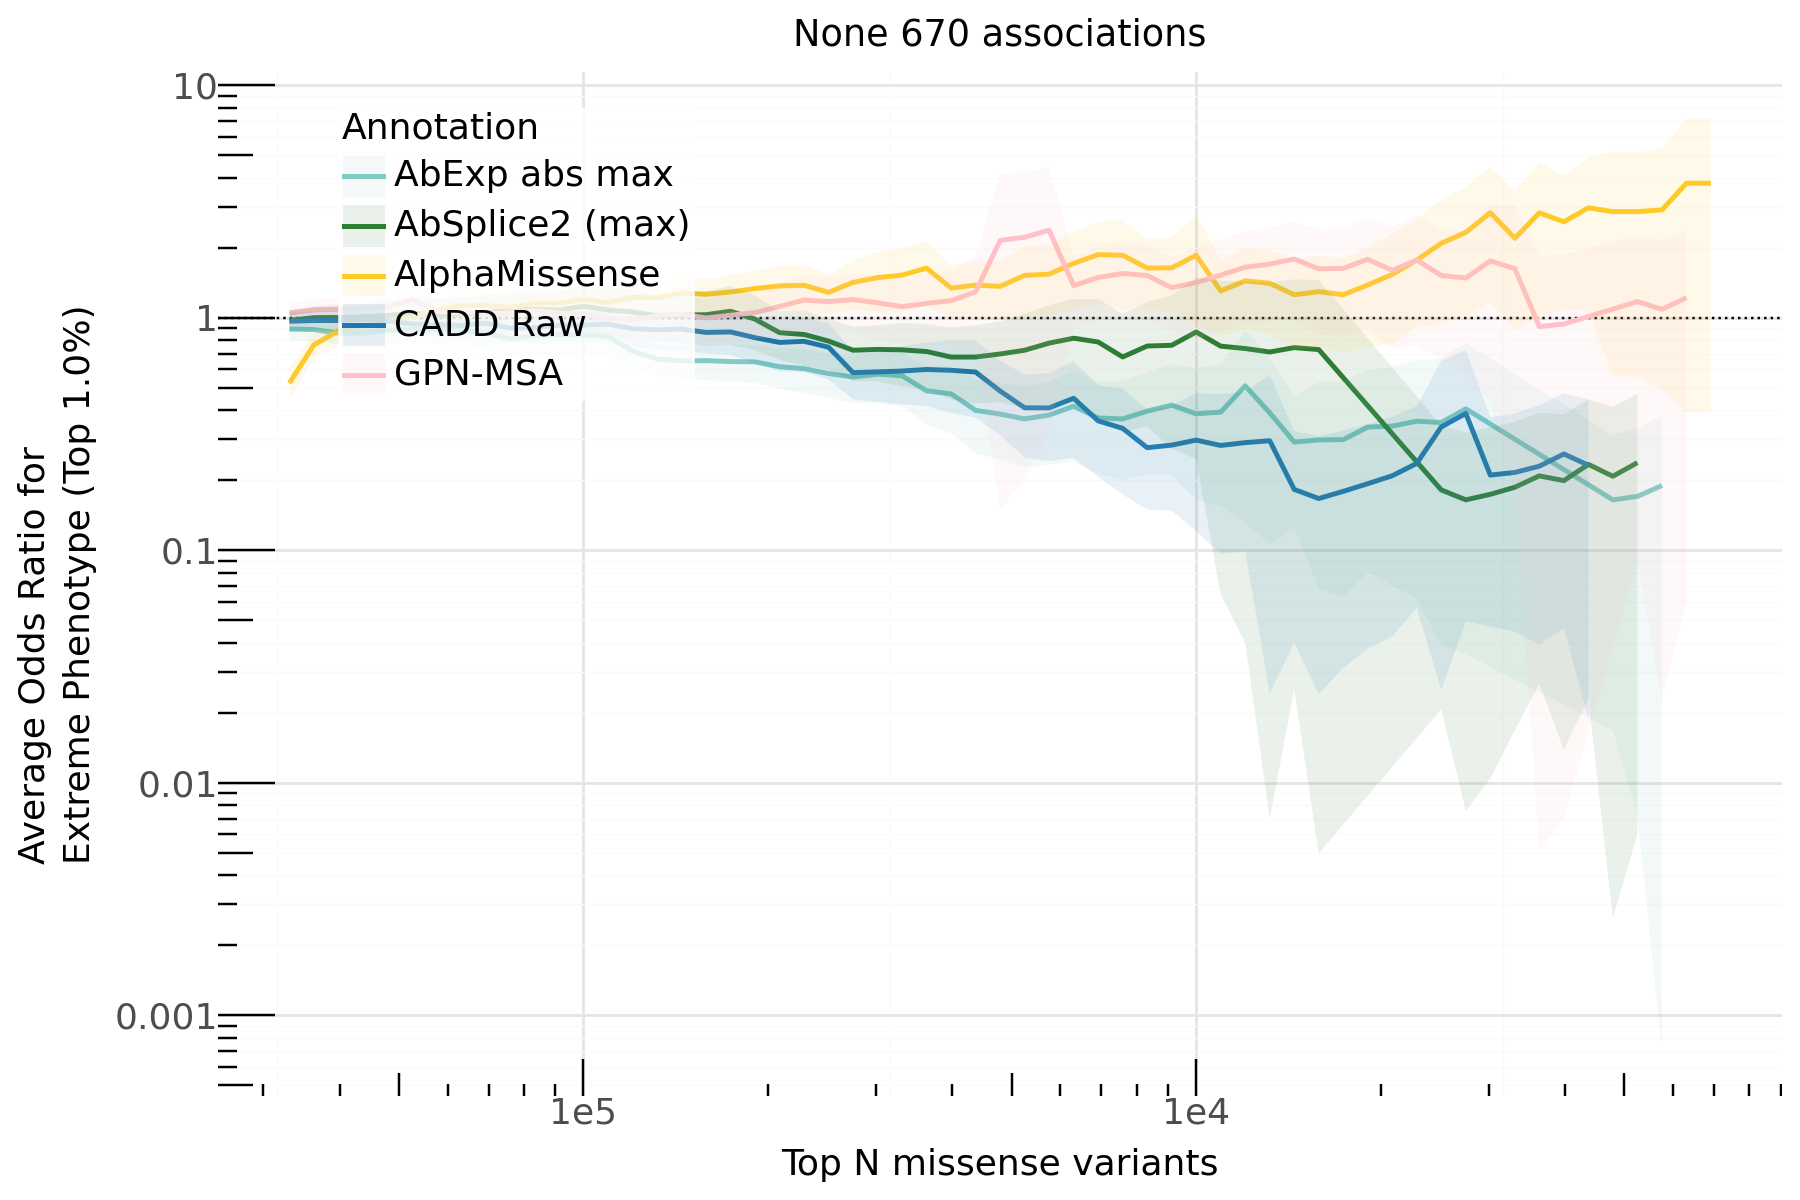

In [14]:
plot_df = (
    plt_df
    .filter(
        (pl.col('log_rank_cutoff_inv') >= -5.5),
        (pl.col('log_rank_cutoff_inv') <= -3),

        # (pl.col('annotation').is_in(['am_pathogenicity', 'gpn_score', 'absplice2_max']))
        (pl.col('annotation').is_in(['am_pathogenicity', 'gpn_score', 'absplice2_max', 'abexp_abs_max', 'cadd_raw']))
        # (pl.col('annotation').is_in(['am_pathogenicity', 'esmscoremissense', 'gpn_score']))
        # (pl.col('annotation').is_in(['gpn_score', 'cadd_raw', 'pangolin_score', 'delta_score', 'absplice2_max']))
        # (pl.col('annotation').is_in(['gpn_score', 'cadd_raw', 'promoterai_abs', 'fz_RNA_blood_abs_max', 'fz_RNA_all_abs_max']))
        # (pl.col('annotation').is_in(['gpn_score', 'cadd_raw', 'promoterai_abs']))
    )
)

# Generate breaks and labels for x-axis
start_exp = int(np.log10(1/max_rank_cutoff))
end_exp = int(np.log10(1/min_rank_cutoff))
breaks_linear = np.arange(start_exp, end_exp + 1)
labels_sci = [f"1e{-b}" for b in breaks_linear]

color_dict = dict(zip(plt_df['label'], plt_df['color']))
pheno_label = round((1 - or_threshold_pheno) * 100, 1)


or_points = pl.DataFrame({
    'annotation': ['loftee_hc', 'loftee_hc', 'canonical_splice_variant', 'canonical_splice_variant', 'canonical_splice_variant', 'five_prime_utr_variant_consequence_uaug_gained'],
    'region': ['Gene body', 'CDS', 'Intronic', 'Intronic (no alt. CDS)', 'All Splice region', "TSS ± 500bp"],
    'n_vars': [-np.log10(131_682), -np.log10(131_682), -np.log10(1_845), -np.log10(1_764), -np.log10(29_524), -np.log10(1_505)],
    'mean_or': [4.291864, 3.707762, 2.012973, 1.860421, 3.304879, 1.156183],
    'se_or': [0.192267, 0.130931, 0.661604, 0.638351, 0.297136, 0.180272],
}).with_columns(
    ci_low_pheno = pl.col('mean_or') - 1.96 * pl.col('se_or'),
    ci_high_pheno = pl.col('mean_or') + 1.96 * pl.col('se_or'),
)

annotation = 'loftee_hc' #'loftee_hc'
plot_region = "Gene body" #'gene_body'

if plot_region in or_points['region'].unique():
    loftee_point  = [
        geom_point(
            or_points.filter(pl.col('region')==plot_region), 
            aes(x='n_vars', y='mean_or'),
            color='black',
            size=2
        ),
        geom_errorbar(
            or_points.filter(pl.col('region')==plot_region),
            aes(x='n_vars', y='mean_or', ymin='ci_low_pheno', ymax='ci_high_pheno'),
            width=0.01,
        ),
        geom_text(
            or_points.filter(pl.col('region')==plot_region),
            aes(x='n_vars', y='mean_or', label='"LOFTEE HC"'),
            nudge_x=0.1,
            # nudge_y=0.15,
            size=12,
            ha='left'
        )
    ]
else:
    loftee_point = []

(
    ggplot(
        plot_df,
        aes(x='log_rank_cutoff_inv', y='avg_odds_ratio')
    )
    + geom_hline(aes(yintercept=1), color='black', linetype='dotted')
    + geom_line(aes(color='label'), size=1)
    + geom_ribbon(aes(ymin='std_ci_lower', ymax='std_ci_upper', fill='label'), alpha=0.1)
    # + loftee_point
    + scale_fill_manual(values=color_dict)
    + scale_color_manual(values=color_dict)
    + labs(
        title=f"{pheno_list_type} {or_df[['region', 'phenotype']].unique().shape[0]} associations",
        y=f"Average Odds Ratio for\nExtreme Phenotype (Top {pheno_label}%)",
        # x=f"Top N {plot_region} variants",
        x=f"Top N missense variants",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_continuous(
        breaks=breaks_linear,
        labels=labels_sci
    )
    + scale_y_log10()
    + annotation_logticks(sides="lb")
    + theme_minimal()
    + theme(
        figure_size=(9, 6),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        legend_position=(0.1, 0.95), 
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)